# Agricultural Drought Hazard Assessment — Kazakhstan

A workflow adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[DROUGHTS](https://github.com/CLIMAAX/DROUGHTS) GitHub repository for Kazakhstan.
See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html)
page for information on how to run this notebook.

In this workflow we assess the impact of water deficit on crop yields.

The aim is to estimate the potential loss in yield for a given crop in the absence of an
artificial irrigation system compensating for precipitation scarcity. This is particularly
relevant for Kazakhstan's semi-arid regions, which are increasingly prone to prolonged
drought periods making artificial irrigation unfeasible, as well as historically wetter
northern oblasts that have not yet implemented artificial irrigation at large scale but may
experience significant declines in precipitation with future climate change.

## Hazard Assessment Methodology

The starting point of the hazard assessment is the calculation of the soil standard
evapotranspiration (ET0) using the Penman-Monteith equation described by FAO
[(Allen et al., 1998)](https://www.fao.org/3/x0490e/x0490e00.htm). The Penman-Monteith
equation allows to calculate the reference evapotranspiration demand (i.e., how much water
does a standard plant require to live) combining thermal radiation and wind data. ET0 does
not hold any plant-specific information, but represents the climate-driven evapotranspiration
demand for a reference crop.

The standard evapotranspiration is then combined with a series of crop-specific information
to derive the crop standard evapotranspiration (ETc). The crop-specific parameters used to
calculate ETc vary depending on the
[thermal climate zone](https://www.fao.org/publications/card/en/c/2b0a758c-d40d-5706-a80d-32ebd864a57a)
considered. Thus, ETc represents the maximum evapotranspiration potential of each crop for a
given thermal climate zone. From ETc, it is possible to derive the actual crop
evapotranspiration (ETa) using precipitation data to estimate the local water availability for
the plant. Hence, ETa represents a fraction of ETc. Using the equations from the FAO I&D 33
paper [(Doorenbos et al., 1979)](https://www.researchgate.net/publication/259842050_FAO_Irrigation_and_Drainage_Paper_33),
it is then possible to relate the ratio between the rainfed and the maximum evapotranspiration
potential to the crop yield loss (%) in rainfed-only conditions.

The hazard assessment can currently be performed for the 14 crops parameterised in the crop
table, but this can be modified to add any crop the user might be interested in. The
assessment is performed using climate data averaged inter-annually to show the impact of
precipitation scarcity on yield for an average growing season in the selected period.

### Data Substitutions for Kazakhstan

| Component | Original CLIMAAX | This Adaptation |
|---|---|---|
| Administrative boundaries | NUTS2 (EU GISCO API) | Kazakhstan OSM shapefile |
| Climate data | EURO-CORDEX (Copernicus CDS) | ISIMIP3b bias-adjusted (direct download) |
| Scenarios | RCP2.6 / RCP4.5 / RCP8.5 | SSP1-2.6 / SSP3-7.0 |
| Available Water Capacity | Hengl & Gupta (2019) global | Unchanged — global dataset |
| Elevation | USGS GMTED2010 global | Unchanged — global dataset |
| Thermal climate zones | FAO global | Unchanged — global dataset |
| Crop table | FAO-56 global parameters | Unchanged — globally applicable |

## Load Libraries

In [1]:
import gc
import os
import re
import warnings
import zipfile
from pathlib import Path

import pooch
import requests
from tqdm import tqdm

import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import shapely
import xarray as xr
import shapefile
import pyproj
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

c:\Users\dauzo\miniconda3\envs\crabook-kz\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create the Directory Structure

The next cell creates the directory called `agriculture_workflow` in the same directory
where this notebook is saved. Subdirectories for data and results will also be created.
Climate data from ISIMIP3b is stored per-variable under `data/isimip3b/`.

In [2]:
workflow_dir = 'agriculture_workflow'
data_dir     = os.path.join(workflow_dir, 'data')
results_dir  = os.path.join(workflow_dir, 'results')
isimip_dir   = os.path.join(data_dir, 'isimip3b')

os.makedirs(workflow_dir, exist_ok=True)
os.makedirs(data_dir,     exist_ok=True)
os.makedirs(results_dir,  exist_ok=True)
os.makedirs(isimip_dir,   exist_ok=True)

## Define the Studied Area

Instead of a NUTS2 region code, we load Kazakhstan's administrative boundaries from a
local shapefile. Set `selected_oblast` to a specific oblast name (matching the `oblast_en`
field in the shapefile) to restrict the assessment to one region, or leave it as `None`
to assess the full territory of Kazakhstan.

The bounding box is derived from the region geometry and used to clip climate and
ancillary datasets, exactly as in the original workflow.

In [ ]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)
OBLAST_FIELD = 'oblast_en'

kaz = gpd.read_file(SHAPEFILE_PATH)

selected_oblast = None

if selected_oblast is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    region_name = re.sub(r'[^a-zA-Z0-9]', '', selected_oblast)
    region_id   = selected_oblast
else:
    region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)
    region_name = 'Kazakhstan'
    region_id   = 'KAZ'

df           = gpd.GeoSeries.get_coordinates(region_gdf)
coords_user  = df.to_numpy()
region_gdf.geometry.explode(index_parts=True).to_file(
    f'{data_dir}/{region_name}.shp'
)

print(f'Region: {region_id}')
print(f'Lon range: [{coords_user[:,0].min():.2f}, {coords_user[:,0].max():.2f}]')
print(f'Lat range: [{coords_user[:,1].min():.2f}, {coords_user[:,1].max():.2f}]')

C:\Users\dauzo\AppData\Local\Temp\ipykernel_5892\2348028059.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)


Region: KAZ
Lon range: [46.49, 87.32]
Lat range: [40.57, 55.44]


In [ ]:
scale = 0.5

bbox = [
    np.min(coords_user[:,0]) - scale,
    np.min(coords_user[:,1]) - scale,
    np.max(coords_user[:,0]) + scale,
    np.max(coords_user[:,1]) + scale,
]
print(f'Bounding box: {bbox}')

Bounding box: [np.float64(45.99321790000005), np.float64(40.06869019999999), np.float64(87.81563360000001), np.float64(55.94217009999994)]


## Download the Climate Datasets

Climate data is sourced from [ISIMIP3b](https://www.isimip.org/), replacing the
EURO-CORDEX data used in the original workflow. ISIMIP3b provides bias-adjusted
climate projections for *precipitation flux, maximum temperature, minimum temperature,
relative humidity, wind speed* and *solar downward radiation* at 0.5 degree spatial
resolution and *daily* temporal resolution. All six variables required for the FAO-56
Penman-Monteith ET0 calculation are available. Data are downloaded directly from the
ISIMIP file server without an API key.

For this example we download a 5-year timeframe for each needed variable. In this example
the selected timeframe is 2046-2050 and the emission scenario is SSP1-2.6. It is
**recommended** to re-run the workflow using data from different models to test the
results uncertainty.

> **Note on scenarios:** ISIMIP3b uses SSP-based scenarios (`ssp126`, `ssp370`) in place
> of the RCP labels (`rcp26`, `rcp85`) used in the original EURO-CORDEX workflow. SSP1-2.6
> is the closest equivalent to RCP2.6.

In [ ]:
ystart            = 2046
yend              = 2050
scenario_download = 'ssp126'   
scenario          = scenario_download

In [ ]:
DECADE_RANGES = {
    'historical': [(1981,1990),(1991,2000),(2001,2010),(2011,2014)],
    'ssp126':     [(2021,2030),(2031,2040),(2041,2050),(2051,2060),
                   (2061,2070),(2071,2080),(2081,2090),(2091,2100)],
    'ssp370':     [(2021,2030),(2031,2040),(2041,2050),(2051,2060),
                   (2061,2070),(2071,2080),(2081,2090),(2091,2100)],
}

def get_needed_decades(ystart, yend, scenario):
    """Return decade chunks that overlap with [ystart, yend]."""
    return [(s,e) for s,e in DECADE_RANGES[scenario] if s <= yend and e >= ystart]

needed_decades = get_needed_decades(ystart, yend, scenario_download)
print(f'Decade files needed: {needed_decades}')

Decade files needed: [(2041, 2050)]


The cell below allows you to select which ISIMIP3b model you want to use for the
assessment. Insert a number in `model_choice` using the table below. It is
**recommended** to re-run the workflow using data from different models to test
the results uncertainty.

| Number | Model | Experiment member |
|---|---|---|
| 0 | GFDL-ESM4 | r1i1p1f1 |
| 1 | IPSL-CM6A-LR | r1i1p1f1 |
| 2 | MPI-ESM1-2-HR | r1i1p1f1 |
| 3 | MRI-ESM2-0 | r1i1p1f1 |
| 4 | UKESM1-0-LL | r1i1p1f2 |

All five models provide the complete set of six variables required for this workflow
across all scenarios.

In [ ]:
MODEL_NAMES = ['GFDL-ESM4', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'UKESM1-0-LL']
MODEL_LOWER  = {
    'GFDL-ESM4':     'gfdl-esm4',
    'IPSL-CM6A-LR':  'ipsl-cm6a-lr',
    'MPI-ESM1-2-HR': 'mpi-esm1-2-hr',
    'MRI-ESM2-0':    'mri-esm2-0',
    'UKESM1-0-LL':   'ukesm1-0-ll',
}
EXPERIMENT_ID = {
    'GFDL-ESM4':     'r1i1p1f1',
    'IPSL-CM6A-LR':  'r1i1p1f1',
    'MPI-ESM1-2-HR': 'r1i1p1f1',
    'MRI-ESM2-0':    'r1i1p1f1',
    'UKESM1-0-LL':   'r1i1p1f2',
}

model_choice = 2   
model        = MODEL_NAMES[model_choice]
print(f'Selected model: {model}')

Selected model: MPI-ESM1-2-HR


In [ ]:
KAZ_BBOX    = {'lon_min': 46.0, 'lon_max': 88.0, 'lat_min': 40.0, 'lat_max': 56.0}
ISIMIP_BASE = (
    'https://files.isimip.org/ISIMIP3b/InputData/climate/atmosphere/'
    'bias-adjusted/global/daily'
)

VARIABLES = ['tasmax', 'tasmin', 'pr', 'sfcWind', 'hurs', 'rsds']


def clip_to_kaz(ds):
    lat0, lat1 = float(ds.lat[0]), float(ds.lat[-1])
    lat_sl = (slice(KAZ_BBOX['lat_max'], KAZ_BBOX['lat_min'])
              if lat0 > lat1 else
              slice(KAZ_BBOX['lat_min'], KAZ_BBOX['lat_max']))
    return ds.sel(lon=slice(KAZ_BBOX['lon_min'], KAZ_BBOX['lon_max']), lat=lat_sl)


def download_variable(variable, model, scenario, ystart, yend):
    var_dir = Path(isimip_dir) / variable
    var_dir.mkdir(parents=True, exist_ok=True)
    decades = get_needed_decades(ystart, yend, scenario)
    m_low   = MODEL_LOWER[model]
    exp_id  = EXPERIMENT_ID[model]

    for s, e in decades:
        fname    = f'{m_low}_{exp_id}_w5e5_{scenario}_{variable.lower()}_global_daily_{s}_{e}.nc'
        out_path = var_dir / f'{model}_{scenario}_{s}_{e}_kaz_{variable}.nc'

        if out_path.exists():
            print(f'  Cached: {variable} {s}-{e}')
            continue

        url      = f'{ISIMIP_BASE}/{scenario}/{model}/{fname}'
        tmp_path = Path(isimip_dir) / f'_tmp_{fname}'

        if tmp_path.exists():
            tmp_path.unlink()

        print(f'  Downloading: {fname}')
        try:
            with requests.get(url, stream=True, timeout=600) as r:
                r.raise_for_status()
                total = int(r.headers.get('content-length', 0))
                with open(tmp_path, 'wb') as f:
                    with tqdm(total=total, unit='B', unit_scale=True,
                              unit_divisor=1024, desc=f'{variable} {s}-{e}',
                              ncols=80) as pbar:
                        for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                            f.write(chunk)
                            pbar.update(len(chunk))
        except Exception as ex:
            print(f'  ERROR downloading: {ex}')
            if tmp_path.exists(): tmp_path.unlink()
            continue

        try:
            ds_global = xr.open_dataset(tmp_path)
            ds_kaz    = clip_to_kaz(ds_global)[[variable.lower()]].load()
            ds_global.close()
            gc.collect()

            ds_kaz.attrs = {}
            ds_kaz[variable.lower()].attrs = {}
            ds_kaz.to_netcdf(out_path)
            ds_kaz.close()
            gc.collect()
            tmp_path.unlink()
            print(f'  Saved: {out_path.name}')
        except Exception as ex:
            print(f'  ERROR processing: {ex}')
            try:
                ds_global.close()
            except Exception:
                pass
            if tmp_path.exists(): tmp_path.unlink()

> **Warning:** The download could take several minutes per variable depending on your
> internet speed. Once started, the progress bar below each cell will keep you updated.
> Re-running the cell will resume from where it left off — already downloaded files are
> skipped automatically.

In [ ]:
for var in VARIABLES:
    print(f'\n--- {var} ---')
    download_variable(var, model, scenario_download, ystart, yend)
print('\nAll downloads complete.')


--- tasmax ---
  Cached: tasmax 2041-2050

--- tasmin ---
  Cached: tasmin 2041-2050

--- pr ---
  Cached: pr 2041-2050

--- sfcWind ---
  Cached: sfcWind 2041-2050

--- hurs ---
  Cached: hurs 2041-2050

--- rsds ---
  Cached: rsds 2041-2050

All downloads complete.


### Explore the Data

The downloaded files from ISIMIP3b follow the naming convention:

    {model}_{scenario}_{start}_{end}_kaz_{variable}.nc

Load one of the files and explore its content and structure. Notice the dimensions,
coordinates, data variables and attributes, as well as the regular latitude/longitude
grid (in contrast to the rotated-pole grid used by EURO-CORDEX).

In [10]:
var_dir      = Path(isimip_dir) / 'tasmax'
example_file = sorted(var_dir.glob(f'{model}_{scenario_download}_*_kaz_tasmax.nc'))[0]
dataset_example = xr.open_dataset(example_file)
dataset_example

<xarray.Dataset> Size: 39MB
Dimensions:  (time: 3652, lat: 32, lon: 84)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2041-01-01T12:00:00 ... 2050-12-31T12...
  * lat      (lat) float64 256B 55.75 55.25 54.75 54.25 ... 41.25 40.75 40.25
  * lon      (lon) float64 672B 46.25 46.75 47.25 47.75 ... 86.75 87.25 87.75
Data variables:
    tasmax   (time, lat, lon) float32 39MB ...

### Extract the Climate Data for the Studied Region

In the cell below the climate datasets are cut to the studied region bounding box and
averaged so that the final datasets are composed of 365 values representing the
inter-annual mean of the studied period. Thus, the assessment refers to a 'typical'
annual growing season in the selected timeframe.

Because ISIMIP3b uses a regular latitude/longitude grid, coordinate handling is simpler
than for EURO-CORDEX: no rotated-pole reprojection is required.

In [ ]:
time_slice = slice(str(ystart), str(yend))


def open_variable(variable, model, scenario, time_slice):
    var_dir = Path(isimip_dir) / variable
    files   = sorted(var_dir.glob(f'{model}_{scenario}_*_kaz_{variable}.nc'))
    if not files:
        raise FileNotFoundError(f'No files found for {variable}/{model}/{scenario}')
    ds = xr.open_mfdataset(files, combine='by_coords').sortby('lat')
    return ds.sel(time=time_slice)


def doy_mean(ds):
    return ds.convert_calendar('noleap').groupby('time.dayofyear').mean()

In [ ]:
ds_tasmax = open_variable('tasmax', model, scenario_download, time_slice)
Tmax = doy_mean(ds_tasmax['tasmax']).to_numpy() - 273.15

ds_tasmin = open_variable('tasmin', model, scenario_download, time_slice)
Tmin = doy_mean(ds_tasmin['tasmin']).to_numpy() - 273.15

ds_precipitation = open_variable('pr', model, scenario_download, time_slice)
precipitation = doy_mean(ds_precipitation['pr']).to_numpy() * 86400

ds_ws = open_variable('sfcWind', model, scenario_download, time_slice)
ws = doy_mean(ds_ws['sfcwind']).to_numpy() * (4.87 / np.log(67.8 * 10 - 5.42))
ws[ws < 0] = 0

ds_hurs = open_variable('hurs', model, scenario_download, time_slice)
relhum = doy_mean(ds_hurs['hurs']).to_numpy()

ds_rsds = open_variable('rsds', model, scenario_download, time_slice)
rad = doy_mean(ds_rsds['rsds']).to_numpy() * 0.0864

In [ ]:
lons = ds_tasmax['lon'].to_numpy()
lats = ds_tasmax['lat'].to_numpy()
lon_grid, lat_grid = np.meshgrid(lons, lats)
coords_11    = np.hstack([lon_grid.reshape(-1, 1), lat_grid.reshape(-1, 1)])
raster_shape = (len(lats), len(lons))

print(f'Climate grid shape: {raster_shape}  ({raster_shape[0]} lat x {raster_shape[1]} lon)')

Climate grid shape: (32, 84)  (32 lat x 84 lon)


In [49]:
# Check the spatial shape of the extracted climate data
elev_shape_check = raster_shape
print(f'Grid size: {elev_shape_check}')
print(f'This tells us that the extracted area for {region_id} is a '
      f'{raster_shape[0]}x{raster_shape[1]} 0.5 degree pixel grid.')

Grid size: (32, 84)
This tells us that the extracted area for KAZ is a 32x84 0.5 degree pixel grid.


## Download the Available Water Capacity, Elevation and Thermal Climate Zones Datasets

To calculate the crop evapotranspiration potential (ETc) we need information about the
local Available Water Capacity, elevation and thermal climate zone. These three datasets
are globally available and are used unchanged from the original CLIMAAX workflow.

### 1. Available Water Capacity

The available water capacity (AWC) represents the maximum amount of water the soil can
store within a certain depth. In this workflow we use data for soil depths of 0-200 cm.
The data are sourced from [Hengl and Gupta (2019)](https://zenodo.org/records/2629149)
and represent the 1950-2017 historical average. The cell below downloads the data as a
.tif file (~5 GB) from the Zenodo repository.

In [50]:
url      = 'doi:10.5281/zenodo.2629149/sol_available.water.capacity_usda.mm_m_250m_0..200cm_1950..2017_v0.1.tif'
filename = 'sol_available.water.capacity_usda.mm_m_250m_0..200cm_1950..2017_v0.1.tif'
pooch.retrieve(
    url=url, known_hash='md5:07129d7ed5e7d1457677bdedee926b27',
    fname=filename, path=data_dir, downloader=pooch.DOIDownloader()
)

'C:\\Users\\dauzo\\Models\\crabook-kazakhstan\\crabook\\notebooks\\workflows\\DROUGHTS\\02_agriculture_drought\\agriculture_workflow\\data\\sol_available.water.capacity_usda.mm_m_250m_0..200cm_1950..2017_v0.1.tif'

### 2. Elevation

Elevation data are sourced from the USGS GMTED2010 digital elevation model
[(Danielson & Gesch, 2011)](https://pubs.usgs.gov/of/2011/1073/). The cell below
downloads the DEM at 30 arc-second resolution as a .zip folder and extracts it.

In [51]:
url      = 'https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/topo/downloads/GMTED/Grid_ZipFiles/mn30_grd.zip'
filename = 'mn30_grd.zip'
pooch.retrieve(url=url, fname=filename, known_hash=None, path=data_dir)
with zipfile.ZipFile(f'{data_dir}/mn30_grd.zip', 'r') as zObject:
    zObject.extractall(path=data_dir)

### 3. Thermal Climate Zones

The thermal climate zones represent a classification of global climates in 8 categories
characterised by different annual temperature ranges and rain seasons
[(Van Velthuizen et al., 2007)](https://www.fao.org/publications/card/en/c/2b0a758c-d40d-5706-a80d-32ebd864a57a).
Kazakhstan spans primarily zones 6 (warm temperate) and 7 (cool temperate/boreal),
reflecting its continental climate. The cell below downloads the thermal climate zones
raster from the FAO repository.

In [52]:
url      = 'https://storage.googleapis.com/fao-maps-catalog-data/uuid/68790fd0-690c-11db-a5a5-000d939bc5d8/resources/Map4_1.zip'
filename = 'Map4_1.zip'
pooch.retrieve(url=url, fname=filename, known_hash=None, path=data_dir)
with zipfile.ZipFile(f'{data_dir}/Map4_1.zip', 'r') as zObject:
    zObject.extractall(path=data_dir)

### Extract the AWC, Elevation and Thermal Climate Zones Data for the Studied Region

The three raster datasets are sampled at the centre of each climate grid cell using
the flat `coords_11` coordinate array built above, then reshaped to match the spatial
dimensions of the climate data. This procedure is identical to the original workflow.

In [ ]:
dff = pd.DataFrame()

raster_path = f'{data_dir}/sol_available.water.capacity_usda.mm_m_250m_0..200cm_1950..2017_v0.1.tif'
with rasterio.open(raster_path) as src:
    dff['AWC'] = [x[0] for x in src.sample(coords_11)]
AWC = dff['AWC'].to_numpy(dtype='float64').reshape(raster_shape)
AWC[AWC < 0] = np.nan

raster_path = f'{data_dir}/mn30_grd/w001001.adf'
with rasterio.open(raster_path) as src:
    dff['elev'] = [x[0] for x in src.sample(coords_11)]
elev = dff['elev'].to_numpy(dtype='float64').reshape(raster_shape)

raster_path = f'{data_dir}/therm_clim/w001001.adf'
with rasterio.open(raster_path) as src:
    dff['clim'] = [x[0] for x in src.sample(coords_11)]

dff.loc[dff['clim'] < 0, 'clim'] = np.nan
dff_clim_mode = dff['clim'].mode(dropna=True)
assert not dff_clim_mode.empty

climate_zone = (
    dff['clim']
    .fillna(dff_clim_mode[0])
    .to_numpy(dtype='float64')
    .reshape(raster_shape)
)

### Explore the Data

Now that we have extracted the data, you can call the `AWC`, `elev` and `climate_zone`
variables to visualise them. All variables are stored as numpy arrays and have the same
shape (lat x lon) as the climate datasets.

To see the shape of the extracted files:

In [54]:
elev.shape

(32, 84)

This tells us that the extracted area for Kazakhstan is formed by a lat-lon grid of
0.5 degree pixels covering the bounding box.

## Import Crop-Specific Information

Crop-specific parameters needed for the hazard assessment are imported from the crop table.
The cell below reads the crop table file and prints it. The FAO-56 crop coefficients and
yield response factors are globally standardised and apply directly to Kazakhstan.

> **Tip:** For Kazakhstan, the most agriculturally important crops are wheat (dominant in
> the north), barley, cotton (south), sunflower, and rice (Kyzylorda region). You can
> extend the crop table with local growing season data from the Kazakhstan Statistics
> Committee to improve seasonal timing accuracy.

In [ ]:
crop_table = pd.read_csv(f'{data_dir}/crop_table.csv', index_col=["Crop", "Clim"])

new_rows = []
for crop in crop_table.index.get_level_values('Crop').unique():
    z5 = crop_table.loc[(crop, 5)]
    z7 = crop_table.loc[(crop, 7)]
    z6 = ((z5 + z7) / 2)
    z6['Type'] = int(z7['Type'])          
    z6['Season start'] = round(z6['Season start'])
    z6['Season End']   = round(z6['Season End'])
    z6.name = (crop, 6)
    new_rows.append(z6)

crop_table = pd.concat([crop_table, pd.DataFrame(new_rows)])
crop_table.index = pd.MultiIndex.from_tuples(crop_table.index, names=['Crop', 'Clim'])
crop_table = crop_table.sort_index()

In [ ]:
crop_table.loc[(slice(None), 7), :]

,,FAO_Code,Kc_in,Kc_mid,Kc_end,lgp_f1,lgp_f2,lgp_f3,lgp_f4,Season start,Season End,RD1,RD2,DF,Type,Ky
Crop,Clim,,,,,,,,,,,,,,,
barley,7,114.0,0.30,1.15,0.25,0.477612,0.223881,0.223881,0.074627,320.0,290.0,0.2,1.00,0.55,1.0,1.00
beans,7,176.0,0.40,1.15,0.35,0.250000,0.250000,0.300000,0.200000,166.0,266.0,0.2,0.80,0.45,1.0,1.15
chickpea,7,191.0,1.00,0.35,0.40,0.318182,0.227273,0.272727,0.181818,105.0,215.0,0.2,0.80,0.50,1.0,0.60
lentil,7,201.0,0.40,1.10,0.30,0.133333,0.200000,0.400000,0.266667,121.0,271.0,0.2,0.70,0.50,1.0,1.00
maize,7,113.0,0.30,1.20,0.50,0.200000,0.266667,0.333333,0.200000,136.0,286.0,0.2,1.00,0.55,1.0,1.50
potato,7,121.0,0.50,1.15,0.75,0.272727,0.181818,0.424242,0.121212,122.0,287.0,0.2,0.40,0.35,1.0,1.10
rapeseed,7,270.0,0.35,1.15,0.35,0.200000,0.400000,0.200000,0.200000,136.0,316.0,0.2,1.00,0.60,1.0,1.00
rice,7,112.0,1.05,1.20,0.90,0.166667,0.166667,0.444444,0.222222,136.0,316.0,0.2,0.50,0.20,1.0,1.35
sorghum,7,152.0,0.30,1.00,0.55,0.153846,0.269231,0.346154,0.230769,153.0,283.0,0.2,1.00,0.55,1.0,0.90


## Hazard Calculation

Now that we have imported all the data, we can begin the hazard quantification. First,
select the crops to assess. In this example we use wheat and maize — both widely grown
in Kazakhstan.

In [ ]:
crop_list = ['wheat', 'maize']

> **Warning:** Write the crop names inside `crop_list` exactly as they appear in the
> crop table.

> **Important:** You can select as many crops as you want, but the more crops selected,
> the longer the workflow will take to complete. Over the full Kazakhstan grid
> (~21 x 27 pixels at 0.5 degrees) the loop is significantly faster than over
> EURO-CORDEX's higher-resolution regional grids.

In [ ]:
nlat = Tmax.shape[-2]
nlon = Tmax.shape[-1]
out_shape = (nlat, nlon, len(crop_list), 365)

Irr_req         = np.zeros(out_shape)
ETa_rf          = np.zeros(out_shape)
ETa_irr         = np.zeros(out_shape)
yield_loss_perc = np.zeros(out_shape[:-1])

kc_daily                = np.zeros(out_shape)
ks_daily                = np.zeros(out_shape)
deficit_meteo_daily     = np.zeros(out_shape)
daily_rooting_depth_all = np.zeros(out_shape)
prec_eff_daily          = np.zeros(out_shape)
ET0_daily               = np.zeros(out_shape)

### Reference Soil Evapotranspiration Potential (ET0)

The cell below defines an auxiliary function to compute the daily reference
evapotranspiration potential (ET0) in every grid cell of the selected region following
the FAO-56 methodology [(Allen et al., 1998)](https://www.fao.org/3/x0490e/x0490e00.htm).

In [ ]:
def saturation_pressure(T):
    return 0.6108 * np.exp((17.27 * T) / (T + 237.3))   # T in degC


def FAO_56_ET0(Tmax, Tmin, relhum, ws, lat_radians, elev, rad, albedo_crop, day):
    Tmean = 0.5 * (Tmin + Tmax)
    es = 0.5 * (saturation_pressure(Tmax) + saturation_pressure(Tmin))
    ea = relhum / 100 * es
    P_barometrica = 101.3 * ((293 - 0.0065 * elev) / 293)**5.26
    gamma = (P_barometrica * 0.001013) / (0.622 * 2.45)
    Delta = 4098 * (0.6108 * np.exp((17.27 * Tmean) / (Tmean + 237.3))) / ((Tmean + 237.3)**2)
    DT = Delta / (Delta + gamma * (1 + 0.34 * ws))
    PT = gamma  / (Delta + gamma * (1 + 0.34 * ws))
    TT = (900 / (Tmean + 273.15)) * ws

    dist_sun   = 1 + 0.0033 * np.cos(2 * np.pi / 365 * day)
    sol_decl   = 0.409 * np.sin(0.0172 * day - 1.39)
    suns_angle = np.arccos(-np.tan(lat_radians) * np.tan(sol_decl))
    Ra  = 37.6 * dist_sun * (
        suns_angle * np.sin(lat_radians) * np.sin(sol_decl)
        + np.cos(lat_radians) * np.cos(sol_decl) * np.sin(suns_angle)
    )
    Rs0  = (0.75 + 2.0e-5 * elev) * Ra
    Rnet = (rad * (1 - albedo_crop)) - (
        4.903e-9
        * 0.5 * ((Tmax + 273.15)**4 + (Tmin + 273.15)**4)
        * (0.34 - 0.14 * np.sqrt(ea))
        * (1.35 * np.where(rad / Rs0 <= 1, rad / Rs0, 1) - 0.35)
    )

    return (0.408 * Rnet * DT) + (PT * TT * (es - ea))


def growing_period_mask(days, start, end):
    if end >= start:
        return (start <= days) & (days <= end)
    else:
        return (days <= end) | (start <= days)

### Yield Percentage Reduction

First we create a DataFrame to store the yield loss results, containing grid cell
coordinates, the selected SSP scenario and the start and end years of the studied
period. This DataFrame is saved as a .csv spreadsheet and serves as input for the
risk assessment workflow.

In [60]:
yield_file = pd.DataFrame(columns=['rcp', 'start_year', 'end_year', 'lat', 'lon', *crop_list])
yield_file['lon']        = np.round(coords_11[:, 0], decimals=3)
yield_file['lat']        = np.round(coords_11[:, 1], decimals=3)
yield_file['rcp']        = scenario
yield_file['start_year'] = int(ds_tasmax['time.year'][0].values)
yield_file['end_year']   = int(ds_tasmax['time.year'][-1].values)

In [ ]:
albedo_crop  = 0.23
lat_radians  = np.deg2rad(coords_11[:, 1]).reshape((nlat, nlon))
days_of_year = np.arange(365)

for i, crop in enumerate(crop_list):
    initial_SM    = AWC.copy()
    deficit_start = AWC - initial_SM

    for lat in tqdm(range(nlat), desc=f'{crop}'):
        for lon in range(nlon):
            row = crop_table.loc[(crop, int(climate_zone[lat, lon]))]

            s = row.loc['Season start']
            h = row.loc['Season End']

            LGP  = h - s + (1 if s < h else 366)
            L1   = round(LGP * row.loc['lgp_f1'])
            L2   = round(LGP * row.loc['lgp_f2'])
            L3   = round(LGP * row.loc['lgp_f3'])
            L12  = L1 + L2
            L123 = L12 + L3
            L4   = LGP - L123

            kc_in  = row.loc['Kc_in']
            kc_mid = row.loc['Kc_mid']
            kc_end = row.loc['Kc_end']

            RD = row.loc[['RD1', 'RD2']].values

            soil_moisture = initial_SM[lat, lon]

            for day in days_of_year:
                day_rel = (day - s) % 365

                ET0 = FAO_56_ET0(
                    Tmax[day, lat, lon], Tmin[day, lat, lon], relhum[day, lat, lon],
                    ws[day, lat, lon], lat_radians[lat, lon], elev[lat, lon],
                    rad[day, lat, lon], albedo_crop, day
                )
                ET0_daily[lat, lon, i, day] = ET0

                if day == 0:
                    prec_eff = precipitation[day, lat, lon]
                else:
                    prec_eff = ETa_irr[lat, lon, i, day-1] + soil_moisture + precipitation[day, lat, lon]
                    if precipitation[day, lat, lon] < prec_eff:
                        prec_eff = precipitation[day, lat, lon]
                prec_eff_daily[lat, lon, i, day] = prec_eff


                if day_rel < 0:
                    kc = kc_in
                elif day_rel < L1 - 1:
                    kc = kc_in
                elif day_rel < L12 - 1:
                    kc = kc_in + ((day_rel - L1 + 1) / L2) * (kc_mid - kc_in)
                elif day_rel < L123 - 1:
                    kc = kc_mid
                elif day_rel < LGP:
                    kc = kc_mid + ((day_rel - L123 + 1) / L4) * (kc_end - kc_mid)
                else:
                    kc = kc_in
                kc_daily[lat, lon, i, day] = kc

                if row.loc['Type'] == 1:
                    if day_rel < 0:
                        daily_rooting_depth = RD[0]
                    elif day_rel < L12 - 1:
                        daily_rooting_depth = (RD[1] - RD[0]) / L12 * (day_rel + 1) + RD[0]
                    elif day_rel < LGP:
                        daily_rooting_depth = RD[1]
                    else:
                        daily_rooting_depth = RD[0]
                else:
                    daily_rooting_depth = RD[1]

                if day == 0:
                    deficit_meteo = (AWC[lat, lon] - soil_moisture) * 1000 * daily_rooting_depth
                else:
                    deficit_meteo = (AWC[lat, lon] - soil_moisture) * 1000 * daily_rooting_depth - prec_eff
                deficit_meteo_daily[lat, lon, i, day]     = deficit_meteo
                daily_rooting_depth_all[lat, lon, i, day] = daily_rooting_depth

                TAW = AWC[lat, lon] * daily_rooting_depth
                RAW = TAW * row.loc['DF']

                ks = ((TAW - deficit_meteo) / (TAW - RAW)) if (TAW > 0 and TAW > deficit_meteo) else 0
                if ks > 1:
                    ks = 1
                ks_daily[lat, lon, i, day] = ks

                ETc = ET0 * kc
                ETa = ETc if day == 0 else ETc * ks
                ETa_rf[lat, lon, i, day]  = ETa
                ETa_irr[lat, lon, i, day] = ETc

                deficit_final       = (deficit_meteo + ETa) if (0 < deficit_meteo <= TAW) else TAW
                deficit_final_limit = TAW - ks * (TAW - RAW)

                irrigation = max(0, ETc - ETa)

                total_irr = deficit_final - deficit_final_limit
                Irr_req[lat, lon, i, day] = (
                    irrigation if (total_irr < 0 or total_irr < ETc) else total_irr
                )

                soil_moisture = AWC[lat, lon] - (
                    (deficit_final - Irr_req[lat, lon, i, day]) / (1000 * daily_rooting_depth)
                )

            mask = ~growing_period_mask(days_of_year, s, h) | np.isnan(AWC[lat, lon])
            ETa_rf[lat, lon, i, mask]  = np.nan
            ETa_irr[lat, lon, i, mask] = np.nan

            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', r'Mean of empty slice')
                annual_ETa_rf  = np.nanmean(ETa_rf[lat, lon, i, :])
                annual_ETa_irr = np.nanmean(ETa_irr[lat, lon, i, :])

            yield_loss = row.loc['Ky'] * (1 - annual_ETa_rf / annual_ETa_irr)
            yield_loss_perc[lat, lon, i] = 100. * np.clip(yield_loss, a_min=0., a_max=1.)

    yield_file[crop] = yield_loss_perc[:, :, i].flatten()

maize: 100%|██████████| 32/32 [00:40<00:00,  1.28s/it]


## Data Export

Define labels for output metadata:

In [62]:
label_period      = f'{ystart}-{yend}'
label_model       = model
label_region_id   = region_id
label_region_name = region_name

### Output from the Yield Loss Calculation

In [ ]:
np.save(
    os.path.join(results_dir, f'{label_region_name}_yield_loss_NUMPY'),
    yield_loss_perc
)

yield_file.to_csv(
    os.path.join(results_dir, f'{label_region_name}_yield_loss_SPREADSHEET.csv'),
    index=False
)

In [ ]:
def point_in_shape(row):
    gridpoint = shapely.Point([row['lon'], row['lat']])
    return region_gdf.contains(gridpoint).any()

mask_pts = yield_file.apply(point_in_shape, axis=1)
yield_file[mask_pts].to_csv(
    os.path.join(results_dir, f'{label_region_name}_yield_loss_SPREADSHEET_clipped.csv'),
    index=False
)

### Hazard Indicators for All Selected Crops

Merge computed outputs and export in NetCDF format.

In [65]:
cumulative_precipitation = np.sum(precipitation, axis=0)
cumulative_ET0           = np.sum(np.average(ET0_daily, axis=2), axis=2)

ds_all = xr.Dataset(
    data_vars={
        'AWC': xr.DataArray(AWC, dims=('y', 'x'), attrs={
            'description': 'soil available water capacity'
        }),
        'precip': xr.DataArray(cumulative_precipitation, dims=('y', 'x'), attrs={
            'description': 'annual mean cumulate precipitation'
        }),
        'ET0': xr.DataArray(cumulative_ET0, dims=('y', 'x'), attrs={
            'description': 'cumulative standard evapotranspiration through the growing season'
        }),
        'yield_loss': xr.DataArray(
            np.moveaxis(yield_loss_perc, 2, 0), dims=('crop', 'y', 'x'), attrs={
                'description': 'yield loss from precipitation deficit'
            }
        ),
    },
    coords={
        'lon':      xr.DataArray(lon_grid, dims=('y', 'x')),
        'lat':      xr.DataArray(lat_grid, dims=('y', 'x')),
        'crop':     crop_list,
        'period':   [label_period],
        'scenario': [scenario],
        'model':    [label_model],
    },
    attrs={
        'region_id':   label_region_id,
        'region_name': label_region_name,
    }
)

ds_all.to_netcdf(os.path.join(
    results_dir,
    f'agridrought_hazard_{label_region_id}_{label_model}_{scenario}_{label_period}.nc'
))

## Plotting the Results

The cells below plot the results of the hazard assessment. First, the AWC, precipitation
and ET0 are plotted to help contextualise the yield reduction results. Precipitation and
ET0 are summed across the selected growing season so that the results displayed show the
total rainfall availability and standard evapotranspiration demand.

> **Important:** Areas showing higher cumulate rainfall and lower cumulate standard
> evapotranspiration will be less likely to experience severe yield losses. However,
> it is important to remember that the standard evapotranspiration is only based on
> climate conditions and does not take into account crop-specific parameters (introduced
> in ETa) that might significantly change the final yield results.

In [ ]:
rcp    = scenario
ystart = int(ds_tasmax['time.year'][0].values)
yend   = int(ds_tasmax['time.year'][-1].values)
zoom   = 0.5


def plot_map(data, cmap, label, title, filename):
    fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(
        [bbox[0] - zoom, bbox[2] + zoom, bbox[1] - zoom, bbox[3] + zoom],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    mesh = ax.contourf(lons, lats, data, cmap=cmap, transform=ccrs.PlateCarree())

    sf = shapefile.Reader(f'{data_dir}/{region_name}')
    for shape in sf.shapes():
        parts = list(shape.parts) + [len(shape.points)]
        for j in range(len(parts) - 1):
            pts = shape.points[parts[j]:parts[j+1]]
            x = [p[0] for p in pts]
            y = [p[1] for p in pts]
            ax.plot(x, y, transform=ccrs.PlateCarree(), color='b', linewidth=1.5)

    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label(label, fontsize=13)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{results_dir}/{filename}')
    plt.show()

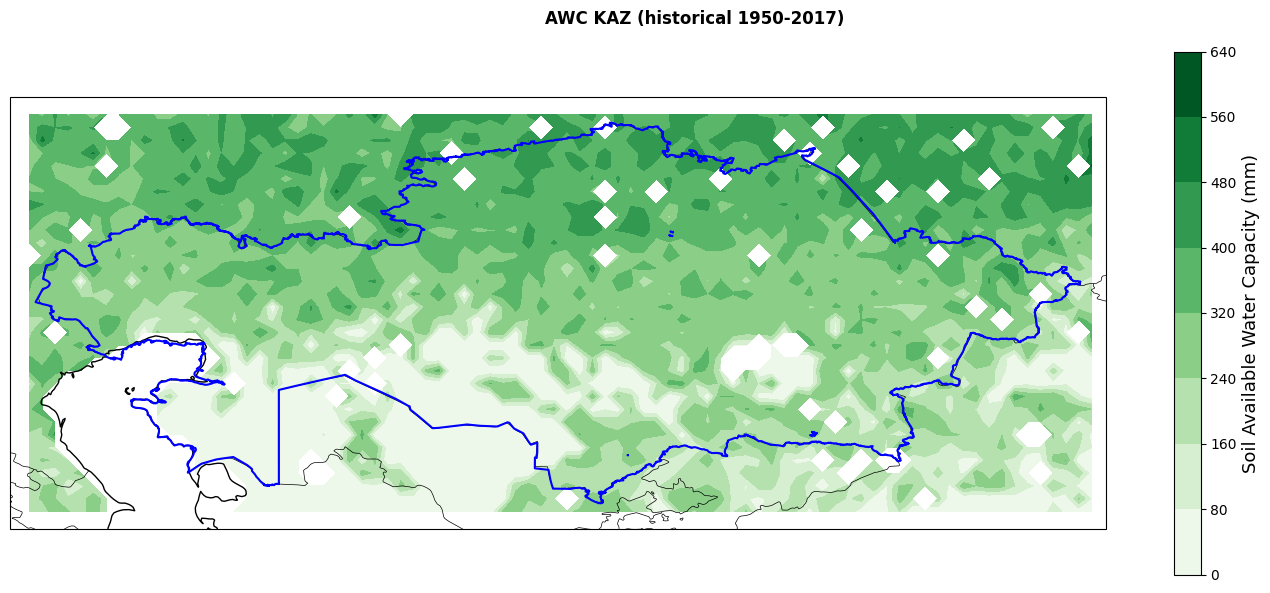

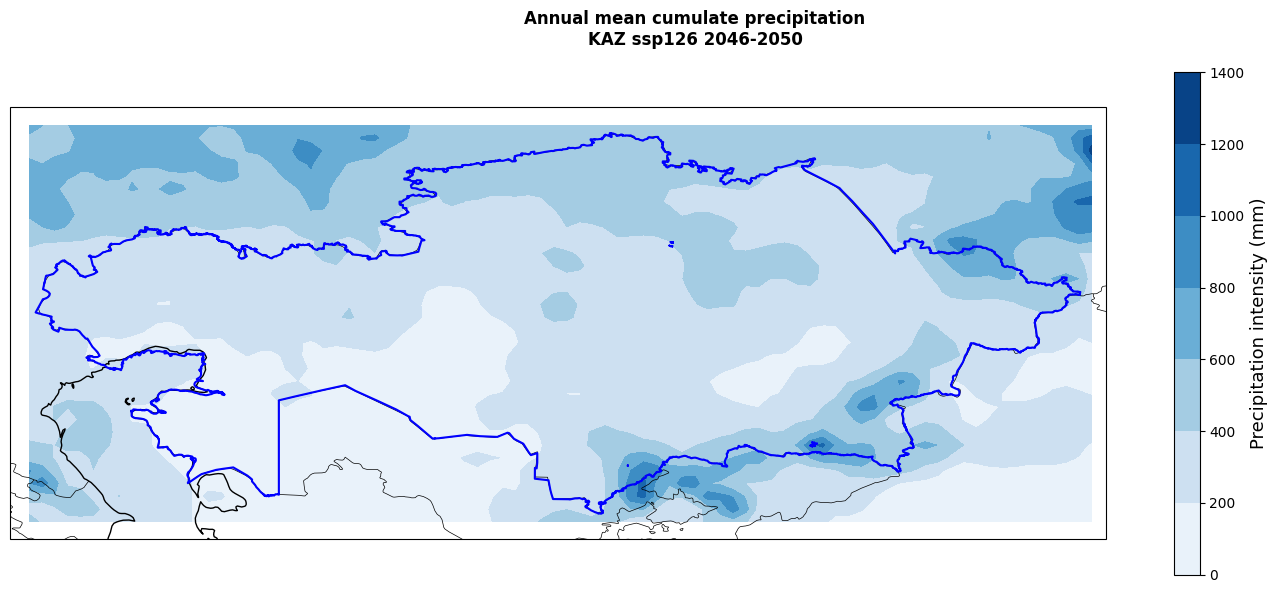

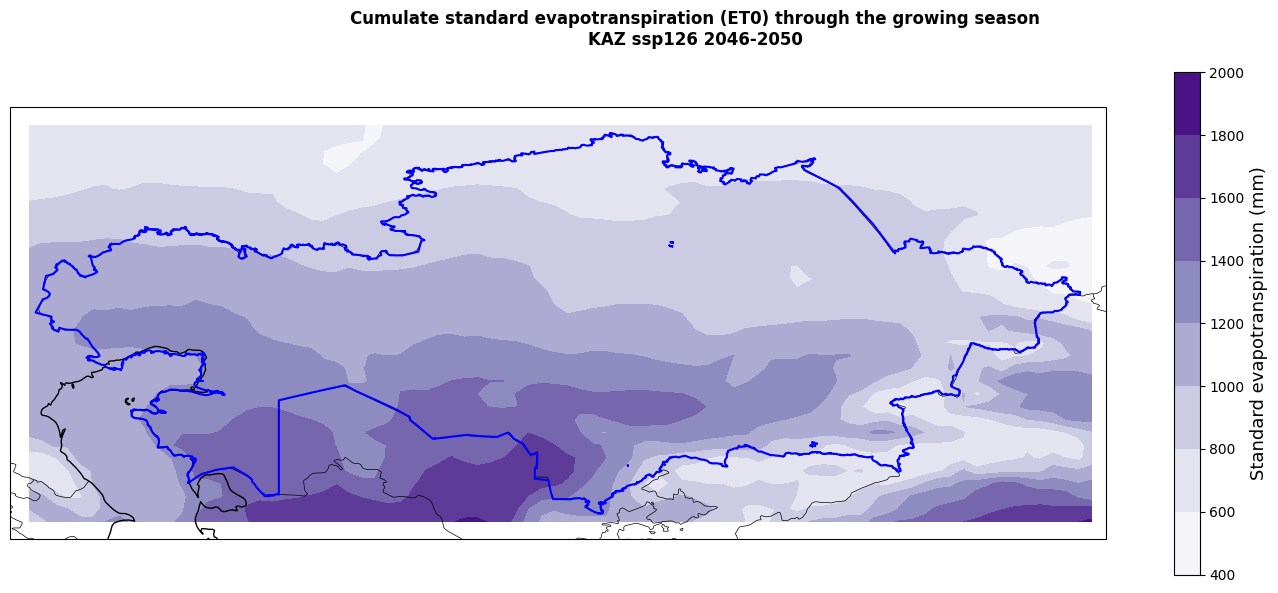

In [ ]:
plot_map(
    AWC,
    cmap='Greens',
    label='Soil Available Water Capacity (mm)',
    title=f'AWC {region_id} (historical 1950-2017)',
    filename=f'{region_id}_AWC.png'
)

plot_map(
    cumulative_precipitation,
    cmap='Blues',
    label='Precipitation intensity (mm)',
    title=f'Annual mean cumulate precipitation\n{region_id} {rcp} {ystart}-{yend}',
    filename=f'{region_id}_Precipitation.png'
)

plot_map(
    cumulative_ET0,
    cmap='Purples',
    label='Standard evapotranspiration (mm)',
    title=(f'Cumulate standard evapotranspiration (ET0) through the growing season\n'
           f'{region_id} {rcp} {ystart}-{yend}'),
    filename=f'{region_id}_ET0.png'
)

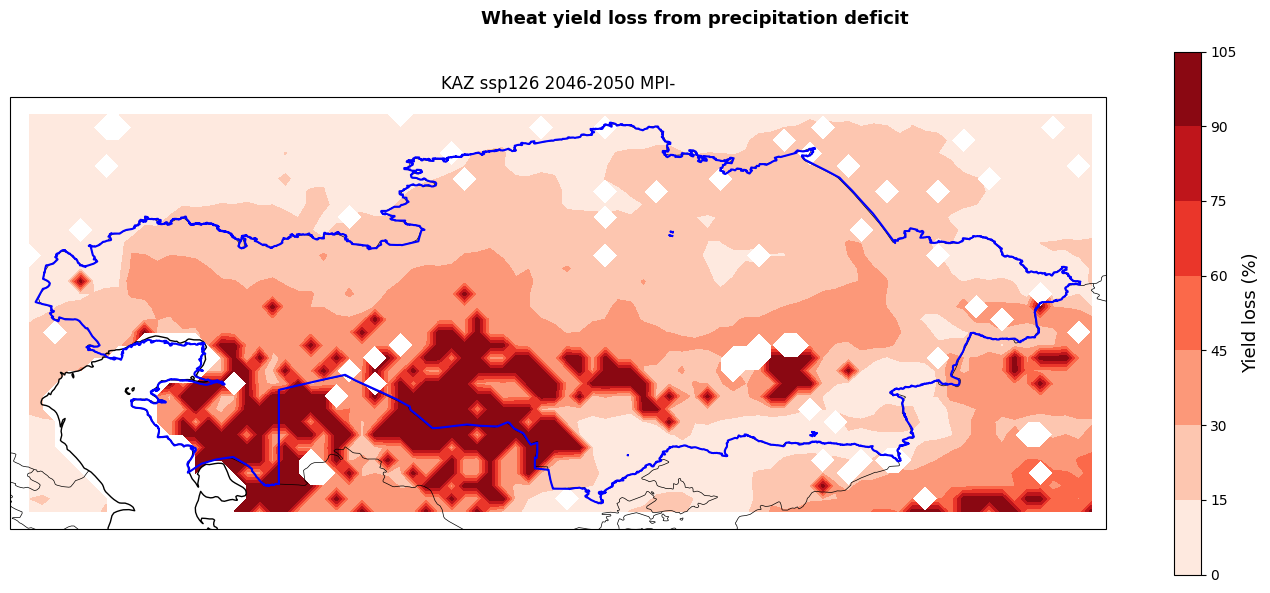

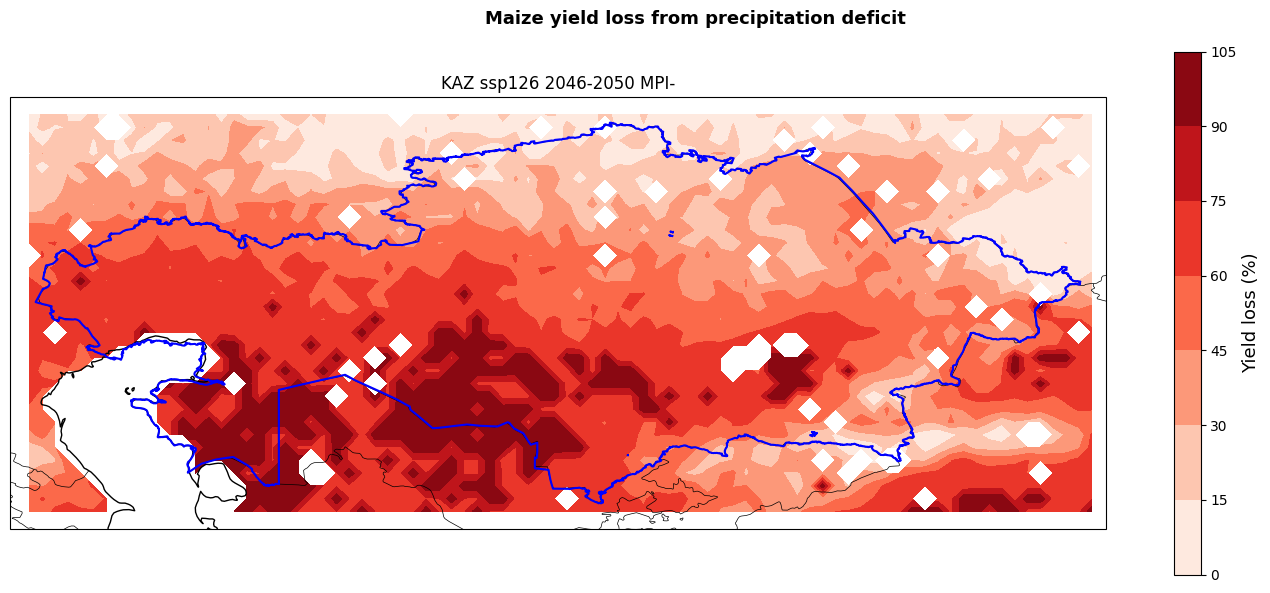

In [ ]:
for a in np.arange(len(crop_list)):
    fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(
        [bbox[0] - zoom, bbox[2] + zoom, bbox[1] - zoom, bbox[3] + zoom],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    mesh = ax.contourf(lons, lats, yield_loss_perc[:, :, a], cmap='Reds',
                       transform=ccrs.PlateCarree())

    sf = shapefile.Reader(f'{data_dir}/{region_name}')
    for shape in sf.shapes():
        parts = list(shape.parts) + [len(shape.points)]
        for j in range(len(parts) - 1):
            pts = shape.points[parts[j]:parts[j+1]]
            x = [p[0] for p in pts]
            y = [p[1] for p in pts]
            ax.plot(x, y, transform=ccrs.PlateCarree(), color='b', linewidth=1.5)

    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label('Yield loss (%)', fontsize=13)

    plt.suptitle(
        f"{crop_list[a].title()} yield loss from precipitation deficit",
        fontsize=13, fontweight='bold'
    )
    plt.title(f"{region_id} {rcp} {ystart}-{yend} {model[:4]}")

    plt.tight_layout()
    plt.savefig(f'{results_dir}/{region_id}_{crop_list[a]}_yield_loss.png')
    plt.show()

The maps show the potential yield loss from irrigation deficit in Kazakhstan for the
selected crops (here wheat and maize), emission scenario (here SSP1-2.6), period
(here 2046-2050) and model (here MPI-ESM1-2-HR). Yield loss is expressed as the
percentage reduction in yield if crops are grown under rainfed-only conditions rather
than fully irrigated.

These maps can be used to understand in which oblasts cropland will potentially
experience the highest hydro-climatic stress. This allows targeting adaptation efforts
in the most affected areas, favouring a cost-effective use of resources. The map provides
a snapshot of a potential future growing season that can be used to guide cropland
expansion towards areas less affected by water stress — particularly relevant for
Kazakhstan's large-scale agricultural expansion in the northern steppe.

## Conclusions

In this workflow we learned:
- How to download and explore ISIMIP3b climate data (six variables) for Kazakhstan.
- How to use and combine these datasets with globally available soil, elevation and
  thermal climate zone data to calculate the actual evapotranspiration potential of
  different crops using the FAO-56 methodology.
- How to derive potential yield losses of different crops without full irrigation from
  the actual evapotranspiration deficit.

The yield loss results produced in this workflow are stored in `.csv` and `.npy` formats
to be explored and later used in the risk assessment workflow.

## References

- Allen, R.G., Pereira, L.S., Raes, D. & Smith, M. (1998) Crop evapotranspiration -
  Guidelines for computing crop water requirements. FAO Irrigation and Drainage Paper 56.
- Danielson, J.J. & Gesch, D.B. (2011) Global multi-resolution terrain elevation data
  2010 (GMTED2010). USGS Open-File Report 2011-1073.
- Doorenbos, J. & Kassam, A.H. (1979) Yield response to water. FAO Irrigation and
  Drainage Paper 33.
- Hengl, T. & Gupta S. (2019). Soil available water capacity in mm derived for 5 standard
  layers at 250 m resolution (v0.1). Zenodo. https://doi.org/10.5281/zenodo.2629149
- ISIMIP (2021). ISIMIP3b bias-adjusted atmospheric climate input data.
  https://doi.org/10.48364/ISIMIP.842396.1
- Mancosu, N. et al. (2016) SIMETAW# - a Model for Agricultural Water Demand Planning.
  Water Resources Management, 30(2), 541-557.
- Steduto, P. et al. (2012) Crop yield response to water. FAO Rome.
- Van Velthuizen, H. et al. (2007) Mapping biophysical factors that influence agricultural
  production and rural vulnerability. FAO.
- Zotarelli, L. et al. (2009) Step by step calculation of the Penman-Monteith
  Evapotranspiration (FAO-56 Method).